In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
import doralite
import gfdl_utils.core as gu
import xarray as xr
import matplotlib.pyplot as plt

In [12]:
odiv_projects = doralite.list_project("odiv")['project']
OM5_experiments = [e for e in odiv_projects if e['title'] == "OM5 experiments"][0]['experiments']

In [22]:
iOM4_dict = doralite.search("iOM4")
master_id = [k for (k,v) in iOM4_dict.items() if "therm" in v][0]

In [23]:
pp = doralite.dora_metadata(master_id)["pathPP"]

In [ ]:
import os
os.listdir(f"{pp}/ice/ts/monthly/5yr/")

In [78]:
pp = doralite.dora_metadata(master_id)["pathPP"]
ppname = "ice_shelf"
out = "ts"
local = gu.get_local(pp, ppname, out)
ds_shelf = gu.open_frompp(pp, ppname, out, local, "1982*", "*", dmget=True)

Issuing dmget command to migrate data to disk. Migration complete.


In [79]:
pp = doralite.dora_metadata(master_id)["pathPP"]
ppname = "ocn"
out = "ts"
local = gu.get_local(pp, ppname, out)
ds = gu.open_frompp(pp, ppname, out, local, "1982*", ["h"], dmget=True)

Issuing dmget command to migrate data to disk. Migration complete.


In [90]:
all_vars = gu.get_allvars(pp)
v_tot = []
for k,vs in all_vars.items():
    for v in vs:
        if v not in v_tot:
            v_tot.append(v)

for v in v_tot:
    print(v)

ssu
mlotst
sos
ssv
tos_max
tos_min
tos
ustar
zos_max
zos_min
zos
hfsso
col_height
MLD_003_max
col_mass
MLD_003_min
evs
MLD_003
ficeberg
MLD_EN1_max
friver
MLD_EN1_min
fsitherm
hf_u_BT_accel_2d
heat_content_cond
hf_rvxv_2d
heat_content_fprec
hf_rvxu_2d
heat_content_massin
heat_content_massout
hfsifrazil
heat_content_surfwater
hfsnthermds
heat_content_vprec
MLD_EN1
Heat_PmE
MLD_EN2
hf_CAu_2d
MLD_EN3
hf_CAv_2d
hf_v_BT_accel_2d
hf_diffu_2d
intz_CAu_2d
hf_diffv_2d
net_massin
hfds
intz_CAv_2d
hf_dudt_2d
intz_gKEv_2d
hf_du_dt_visc_2d
intz_PFu_2d
hf_dvdt_2d
intz_PFv_2d
hf_dv_dt_visc_2d
net_massout
hfevapds
intz_rvxu_2d
hf_gKEu_2d
intz_rvxv_2d
hf_gKEv_2d
intz_u_BT_accel_2d
hfibthermds
opottempmint
hflso
pbo
hf_PFu_2d
prlq
hf_PFv_2d
prsn
hfrainds
intz_v_BT_accel_2d
hfrunoffds
intz_diffu_2d
LwLatSens
intz_diffv_2d
mass_wt
intz_gKEu_2d
rlntds
net_heat_coupler
rsntds
S_adx_2d
S_ady_2d
salt_flux_added
sfdsi
sob
somint
T_adx_2d
T_ady_2d
tauuo
tauvo
taux_bot
taux
tauy_bot
tauy
tob
ubt_dt
umo_2d
vbt_dt

(-85.0, -50.0)

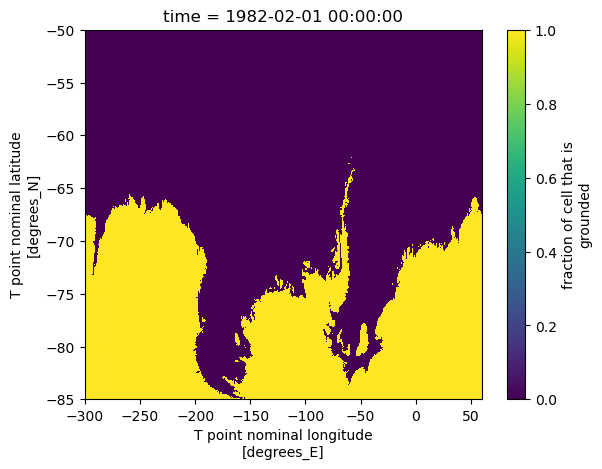

In [99]:
ds_shelf.ice_ground_frac.isel(time=0).plot()
plt.ylim(-85, -50)

(-87.0, -55.0)

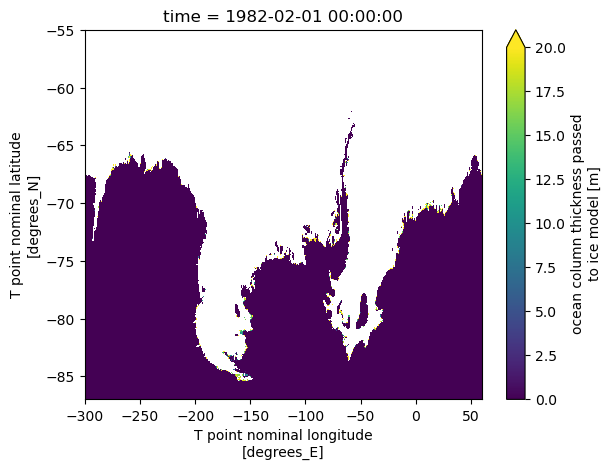

In [108]:
ds_shelf.col_thick.isel(time=0).where(ds_shelf.ice_ground_frac.isel(time=0)).plot(vmin=0, vmax=20)
plt.ylim(-87, -55)

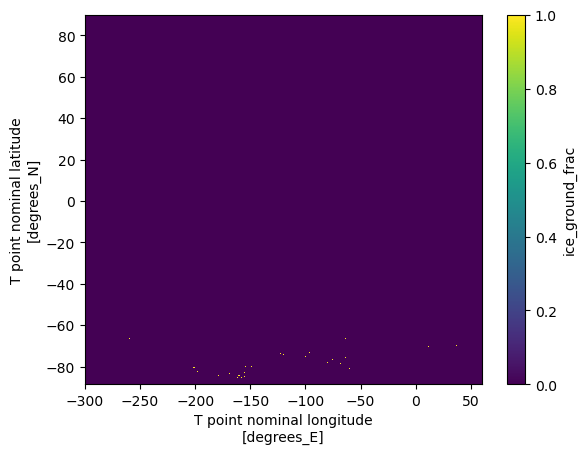

In [110]:
(ds_shelf.ice_ground_frac.max("time") - ds_shelf.ice_ground_frac.min("time")).plot()

(-85.0, -50.0)

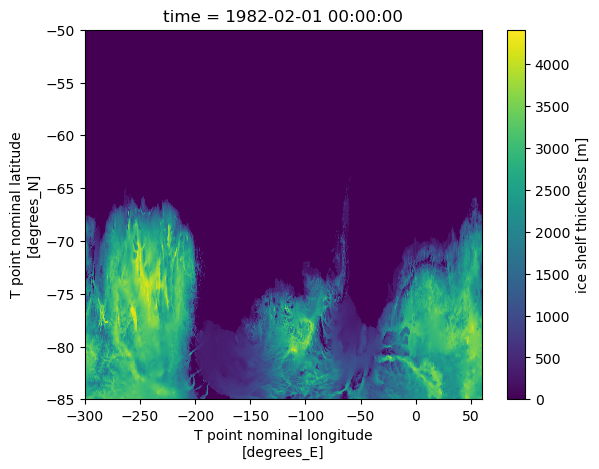

In [82]:
ds_shelf.h_shelf.isel(time=0).plot()
plt.ylim(-85, -50)

(-85.0, -50.0)

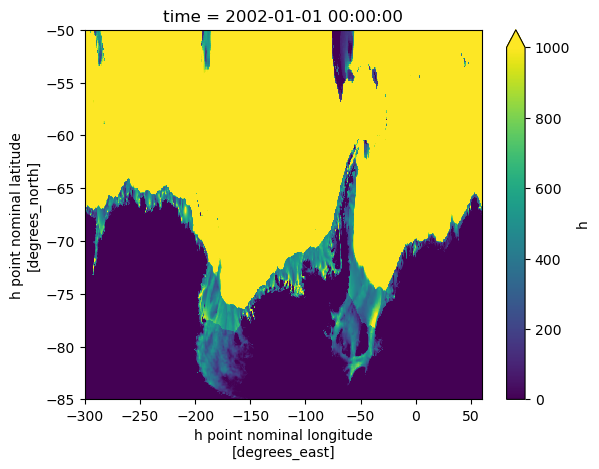

In [69]:
ds["h"].isel(time=-1).sum("zl").plot(vmin=0, vmax=1000)
plt.ylim(-85, -50)

In [71]:
ds["h"]

<xarray.DataArray 'h' (time: 240, zl: 63, yh: 1161, xh: 1440)> Size: 202GB
dask.array<concatenate, shape=(240, 63, 1161, 1440), dtype=float64, chunksize=(60, 63, 1161, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 2kB 1982-02-01 00:00:00 ... 2002-01-01 00:00:00
  * xh       (xh) float64 12kB -299.9 -299.6 -299.4 -299.1 ... 59.38 59.62 59.88
  * yh       (yh) float64 9kB -88.52 -88.42 -88.32 -88.23 ... 89.73 89.84 89.95
  * zl       (zl) float64 504B 1.009e+03 1.014e+03 ... 1.038e+03 1.038e+03
Attributes:
    units:          m
    long_name:      Layer Thickness
    cell_methods:   area:mean zl:sum yh:mean xh:mean time: point
    cell_measures:  volume: volcello area: areacello

In [25]:
gu.get_allvars(pp)

No ts directory in .dec. Can't retrieve variables.
No ts directory in .checkpoint. Can't retrieve variables.


{'ocean_daily': ['ssu',
  'mlotst',
  'sos',
  'ssv',
  'tos_max',
  'tos_min',
  'tos',
  'ustar',
  'zos_max',
  'zos_min',
  'zos'],
 'ocean_monthly': ['hfsso',
  'col_height',
  'MLD_003_max',
  'col_mass',
  'MLD_003_min',
  'evs',
  'MLD_003',
  'ficeberg',
  'MLD_EN1_max',
  'friver',
  'MLD_EN1_min',
  'fsitherm',
  'hf_u_BT_accel_2d',
  'heat_content_cond',
  'hf_rvxv_2d',
  'heat_content_fprec',
  'hf_rvxu_2d',
  'heat_content_massin',
  'heat_content_massout',
  'hfsifrazil',
  'heat_content_surfwater',
  'hfsnthermds',
  'heat_content_vprec',
  'MLD_EN1',
  'Heat_PmE',
  'MLD_EN2',
  'hf_CAu_2d',
  'MLD_EN3',
  'hf_CAv_2d',
  'hf_v_BT_accel_2d',
  'hf_diffu_2d',
  'intz_CAu_2d',
  'hf_diffv_2d',
  'net_massin',
  'hfds',
  'intz_CAv_2d',
  'hf_dudt_2d',
  'intz_gKEv_2d',
  'hf_du_dt_visc_2d',
  'intz_PFu_2d',
  'hf_dvdt_2d',
  'intz_PFv_2d',
  'hf_dv_dt_visc_2d',
  'net_massout',
  'hfevapds',
  'intz_rvxu_2d',
  'hf_gKEu_2d',
  'intz_rvxv_2d',
  'hf_gKEv_2d',
  'intz_u_BT_

In [7]:
doralite.dora_metadata(2194)

{'displayName': None,
 'expLabels': None,
 'expLength': None,
 'expMIP': None,
 'expName': 'om5_b02_GEBCO2020_nnztools_cycle1',
 'expType': None,
 'expYear': None,
 'gfdlHistoryYear': None,
 'id': 2194,
 'jobID': None,
 'master_id': '2194',
 'modelType': 'OM5',
 'owner': 'Jacob.Steinberg',
 'pathAnalysis': '/nbhome/Jacob.Steinberg/fre_om5/FMS2023.01_om5_20230927/om5_b02_GEBCO2020_nnztools_cycle1/',
 'pathDB': '/home/Jacob.Steinberg/fre_om5/FMS2023.01_om5_20230927/om5_b02_GEBCO2020_nnztools_cycle1/gfdl.ncrc5-intel23-prod/db/',
 'pathLog': None,
 'pathPP': '/archive/Jacob.Steinberg/fre_om5/FMS2023.01_om5_20230927/om5_b02_GEBCO2020_nnztools_cycle1/gfdl.ncrc5-intel23-prod/pp/',
 'pathScript': '/lustre/f2/dev/Jacob.Steinberg/fre_om5/FMS2023.01_om5_20230927/om5_b02_GEBCO2020_nnztools_cycle1/ncrc5.intel23-prod/scripts/om5_b02_GEBCO2020_nnztools_cycle1/',
 'pathXML': '/home/jms/ncrc/om5/ocean-only/b02/om5_b02_GEBCO2020_nnztools.xml/',
 'queue': None,
 'refresh': None,
 'requested_id': '2194',


In [8]:
odiv_projects = doralite.list_project("odiv")['project']
OM5_experiments = [e for e in odiv_projects if e['title'] == "OM5 experiments"][0]['experiments']

[e for e in OM5_experiments if e["master_id"]==2194][0]

{'displayName': None,
 'expLabels': None,
 'expLength': None,
 'expMIP': None,
 'expName': 'om5_b02_GEBCO2020_nnztools_cycle1',
 'expType': None,
 'expYear': None,
 'experiment_id': 309,
 'gfdlHistoryYear': None,
 'id': 'odiv-309',
 'jobID': None,
 'master_id': 2194,
 'modelType': 'OM5',
 'owner': 'Jacob.Steinberg',
 'pathAnalysis': '/nbhome/Jacob.Steinberg/fre_om5/FMS2023.01_om5_20230927/om5_b02_GEBCO2020_nnztools_cycle1/',
 'pathDB': '/home/Jacob.Steinberg/fre_om5/FMS2023.01_om5_20230927/om5_b02_GEBCO2020_nnztools_cycle1/gfdl.ncrc5-intel23-prod/db/',
 'pathLog': None,
 'pathPP': '/archive/Jacob.Steinberg/fre_om5/FMS2023.01_om5_20230927/om5_b02_GEBCO2020_nnztools_cycle1/gfdl.ncrc5-intel23-prod/pp/',
 'pathScript': '/lustre/f2/dev/Jacob.Steinberg/fre_om5/FMS2023.01_om5_20230927/om5_b02_GEBCO2020_nnztools_cycle1/ncrc5.intel23-prod/scripts/om5_b02_GEBCO2020_nnztools_cycle1',
 'pathXML': '/home/jms/ncrc/om5/ocean-only/b02/om5_b02_GEBCO2020_nnztools.xml',
 'queue': None,
 'refresh': None,


In [ ]:
pp = doralite.dora_metadata("odiv-230")['pathPP']
local = gu.get_local(pp, ppname, "ts")
path = gu.get_pathspp(pp, ppname, "ts", local, "*", f"*{var}*")
path_static = gu.get_pathstatic(pp, ppname)

#ds = xr.open_mfdataset(path, engine="netcdf4")
ds = gu.open_frompp(pp, ppname, "ts", local, "*", f"*{var}*", engine="netcdf4", dmget=dmget)

In [8]:
def load(var, exp, ppname="ocean_annual", dmget=True):
    pp = doralite.dora_metadata(exp)['pathPP']
    local = gu.get_local(pp, ppname, "ts")
    path = gu.get_pathspp(pp, ppname, "ts", local, "*", f"*{var}*")
    path_static = gu.get_pathstatic(pp, ppname)
    
    #ds = xr.open_mfdataset(path, engine="netcdf4")
    ds = gu.open_frompp(pp, ppname, "ts", local, "*", f"*{var}*", engine="netcdf4", dmget=dmget)
    grid = xr.open_dataset(path_static)
    
    return ds, grid

def deep_TKE_itidal(exp, cutoff_depth=2500, timemean=False, dmget=True):
    ds, grid = load("TKE_itidal", exp, ppname="ocean_annual", dmget=dmget)
    conversion = ds['TKE_itidal']*grid['areacello'].values
    if timemean:
        conversion=conversion.mean('time')

    smoothed_depth = grid.deptho.fillna(0.).rolling({"xh":8, "yh":8}).mean()
    
    total_conversion = conversion.sum(["xh", "yh"]).compute() * 1e-12
    deep_conversion = conversion.where(smoothed_depth.values > cutoff_depth).sum(["xh", "yh"]).compute() * 1e-12
    
    return deep_conversion, total_conversion

om5_b00_GEBCO2020_om4h2_cycle1
Issuing dmget command to migrate data to disk. Migration complete.
om5_b00_dtcpld1800_BBL_c5
Issuing dmget command to migrate data to disk. Migration complete.
om5_b00_dtcpld1800_BBLeff0_c5
Issuing dmget command to migrate data to disk. Migration complete.
om5_b01_kappah2fac1p26
Issuing dmget command to migrate data to disk. Migration complete.
om5_b02_kappah2fac1p26
Issuing dmget command to migrate data to disk. Migration complete.


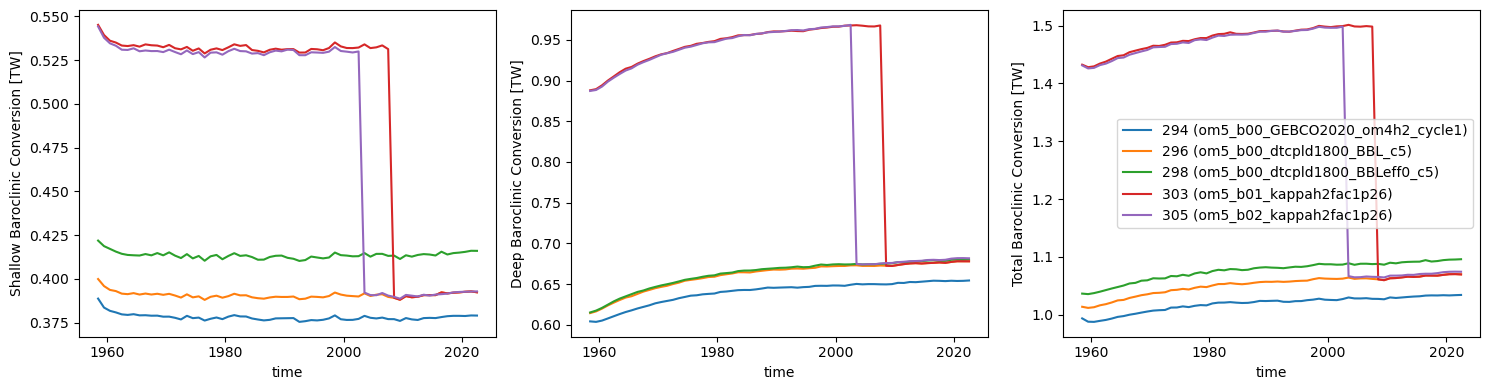

In [31]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 4))
for odiv in ["294", "296", "298", "303", "305"]:#, "299",  "309"]:
    expName = doralite.dora_metadata(f"odiv-{odiv}")['expName']
    print(expName)
    deep, total = deep_TKE_itidal(f"odiv-{odiv}")

    plt.subplot(1,3,1)
    (total-deep).plot(label=f"{odiv} ({expName})")
    plt.ylabel("Shallow Baroclinic Conversion [TW]")
    
    plt.subplot(1,3,2)
    deep.plot(label=f"{odiv} ({expName})")
    plt.ylabel("Deep Baroclinic Conversion [TW]")
    
    plt.subplot(1,3,3)
    (total+2e-3*(np.random.rand()-0.5)).plot(label=f"{odiv} ({expName})") # just to be able to distinguish lines
    plt.ylabel("Total Baroclinic Conversion [TW]")
    
plt.legend()
plt.tight_layout()

### CM

CM4_piControl_C
Issuing dmget command to migrate data to disk. Migration complete.
cm_am4c96l33_b02
Issuing dmget command to migrate data to disk. Migration complete.
cm_am4c96l33_b02_minthick1mm
Issuing dmget command to migrate data to disk. Migration complete.


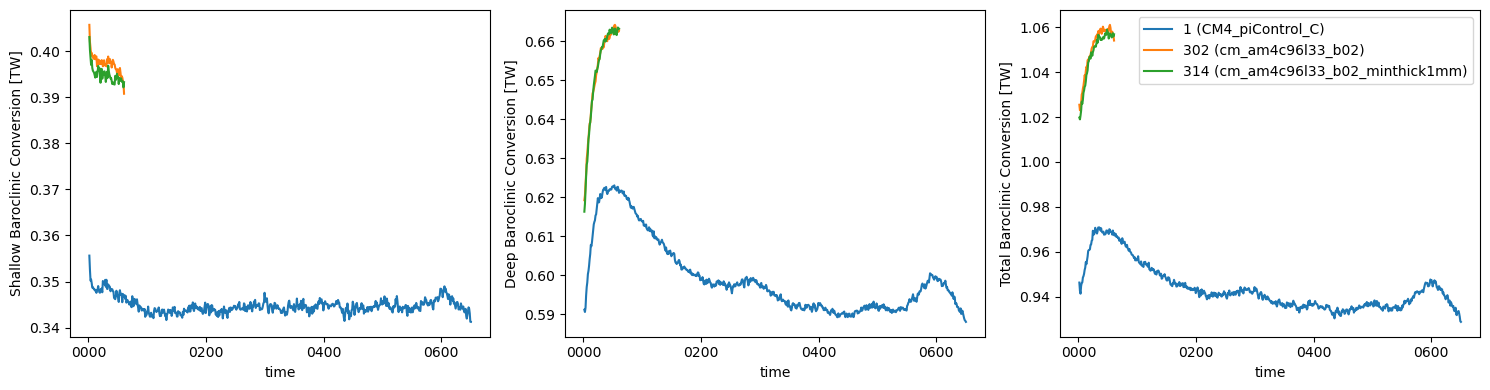

In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(15, 4))
for odiv in ["1", "302", "314"]:#, "299",  "309"]:
    expName = doralite.dora_metadata(f"odiv-{odiv}")['expName']
    print(expName)
    deep, total = deep_TKE_itidal(f"odiv-{odiv}")

    plt.subplot(1,3,1)
    (total-deep).plot(label=f"{odiv} ({expName})")
    plt.ylabel("Shallow Baroclinic Conversion [TW]")
    
    plt.subplot(1,3,2)
    deep.plot(label=f"{odiv} ({expName})")
    plt.ylabel("Deep Baroclinic Conversion [TW]")
    
    plt.subplot(1,3,3)
    (total+2e-3*(np.random.rand()-0.5)).plot(label=f"{odiv} ({expName})") # just to be able to distinguish lines
    plt.ylabel("Total Baroclinic Conversion [TW]")
    
plt.legend()
plt.tight_layout()